# Headere

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# LSTM

A deep learning model using **Long Short-Term Memory (LSTM)** networks to handle sequential data, such as time series or text. The architecture consists of multiple LSTM layers with progressively increasing units (50 → 60 → 80 → 120) to capture complex temporal patterns. Dropout layers are strategically added after each LSTM layer to prevent overfitting, with dropout rates incrementally increasing (0.2 → 0.3 → 0.4 → 0.5). The model outputs a single continuous value through a Dense layer, making it suitable for regression tasks like stock price prediction, weather forecasting, or any sequence-to-one mapping problem.

The code is built using the Keras library and is highly customizable for various sequential data applications. It demonstrates how to construct, train, and evaluate an LSTM-based model for predicting numerical outcomes from time-series inputs.

In [ ]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

def LSTM_model(x_train):
    model = Sequential()
    model.add(LSTM(units = 50, activation='relu', return_sequences= True, input_shape = (x_train.shape[1], 1)))
    model.add(Dropout(0.2))

    model.add(LSTM(units = 60, activation='relu', return_sequences= True))
    model.add(Dropout(0.3))

    model.add(LSTM(units = 80, activation='relu', return_sequences= True))
    model.add(Dropout(0.4))

    model.add(LSTM(units = 120, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(units=1))

    return model

# Reliance

In [ ]:
ticker_symbol = "RELIANCE.NS"


## 1 minute data
**1 minute data for last 5 days**

In [ ]:
df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
df = df.reset_index()
df


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Datetime,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2025-03-07 03:45:00+00:00,1213.000000,1219.099976,1212.599976,1215.800049,0
1,2025-03-07 03:46:00+00:00,1217.050049,1217.400024,1212.000000,1212.349976,72940
2,2025-03-07 03:47:00+00:00,1221.500000,1221.500000,1216.650024,1217.199951,108270
3,2025-03-07 03:48:00+00:00,1221.000000,1221.750000,1219.900024,1221.199951,101131
4,2025-03-07 03:49:00+00:00,1221.000000,1222.400024,1220.150024,1220.800049,72966
...,...,...,...,...,...,...
1858,2025-03-13 09:55:00+00:00,1249.750000,1250.599976,1249.699951,1250.000000,43385
1859,2025-03-13 09:56:00+00:00,1249.750000,1250.000000,1249.050049,1249.599976,52972
1860,2025-03-13 09:57:00+00:00,1249.250000,1250.050049,1249.250000,1249.750000,46189


### Close value

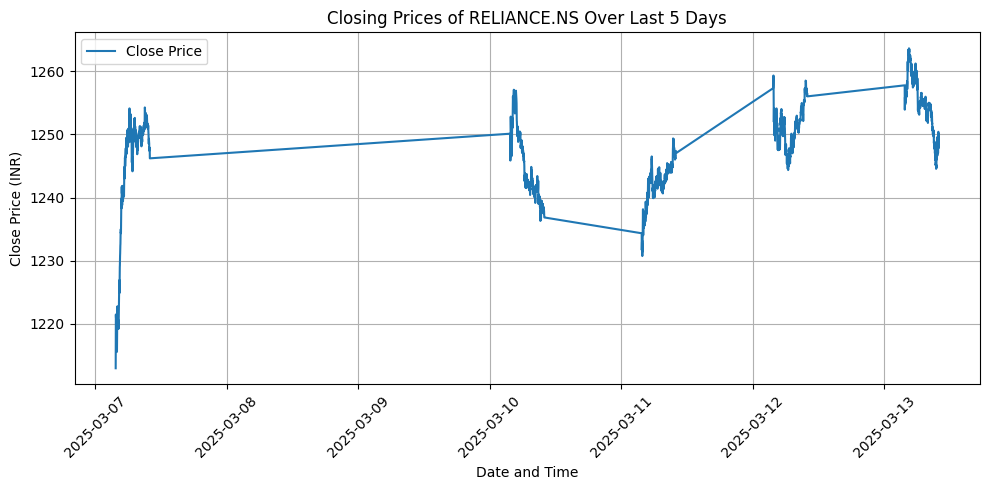

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

The dataset is preprocessed by removing the 'Datetime' column, as it is not directly usable in the model. The 'Close' price column is then split into training and testing sets, with 70% of the data allocated for training and the remaining 30% reserved for testing. This ensures the model is trained on historical data and evaluated on unseen data to assess its performance. The shapes of the resulting datasets confirm the successful split.

In [ ]:
# removing Datetime and Adj Close from data
data = df.drop(columns=['Datetime'])

# spliting data into training and testing
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data['Close'][int(len(data)*0.70):int(len(data))])

print(data_testing.shape)
print(data_training.shape)

(559, 1)
(1304, 1)


<ipython-input-6-f324c3630b80>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data = df.drop(columns=['Datetime'])


The training data is scaled using `MinMaxScaler` to normalize the values between 0 and 1, which is crucial for efficient training of neural networks. After scaling, sequences of data are created to prepare the input (`x_train`) and target (`y_train`) for the model:

- A sliding window approach is used, where each input sequence (`x_train`) consists of the previous 100 time steps, and the corresponding target (`y_train`) is the value at the next time step.
- The `for` loop iterates through the scaled data, appending sequences of 100 time steps to `x_train` and the subsequent value to `y_train`.
- Both `x_train` and `y_train` are converted into NumPy arrays for compatibility with machine learning models.

This process transforms the raw time series data into a supervised learning format suitable for training sequential models like LSTMs.

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.        ],
       [0.08747396],
       [0.18358512],
       ...,
       [0.71922276],
       [0.72570065],
       [0.72138206]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i, 0])

x_train , y_train = np.array(x_train), np.array(y_train)
print(x_train)
print(y_train)

[[[0.        ]
  [0.08747396]
  [0.18358512]
  ...
  [0.64794748]
  [0.66522713]
  [0.66198687]]

 [[0.08747396]
  [0.18358512]
  [0.17278599]
  ...
  [0.66522713]
  [0.66198687]
  [0.69978381]]

 [[0.18358512]
  [0.17278599]
  [0.17278599]
  ...
  [0.66198687]
  [0.69978381]
  [0.71922276]]

 ...

 [[0.88120963]
  [0.88012866]
  [0.87796936]
  ...
  [0.70950196]
  [0.70086214]
  [0.69978381]]

 [[0.88012866]
  [0.87796936]
  [0.87796936]
  ...
  [0.70086214]
  [0.69978381]
  [0.71922276]]

 [[0.87796936]
  [0.87796936]
  [0.88552822]
  ...
  [0.69978381]
  [0.71922276]
  [0.72570065]]]
[0.69978381 0.71922276 0.71706082 ... 0.71922276 0.72570065 0.72138206]


### Train the model

The LSTM model is compiled and trained on the training data (x_train, y_train) for 50 epochs. For testing, the last 100 time steps from the training set are combined with the testing data, scaled, and then split into sequences of 100 time steps (x_test) and corresponding targets (y_test). This ensures the testing data is properly formatted and scaled for evaluation.

In [ ]:
model = LSTM_model(x_train)

model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 16s 272ms/step - loss: 0.2592
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - loss: 0.0196
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 226ms/step - loss: 0.0168
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 217ms/step - loss: 0.0152
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 261ms/step - loss: 0.0122
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - loss: 0.0134
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - loss: 0.0135
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 220ms/step - loss: 0.0129
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 256ms/step - loss: 0.0123
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - loss: 0.0109
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - loss: 0.0115
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - loss: 0.0107
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step - loss: 0.0115
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - loss: 0.0101
Epoch 15/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 218ms

In [ ]:
past_100 = data_training.tail(100)
final_df = pd.concat([past_100, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test)
print(y_test)

[[[0.48311942]
  [0.50129997]
  [0.4909129 ]
  ...
  [0.10130251]
  [0.11688312]
  [0.10649604]]

 [[0.50129997]
  [0.4909129 ]
  [0.44935192]
  ...
  [0.11688312]
  [0.10649604]
  [0.12207665]]

 [[0.4909129 ]
  [0.44935192]
  [0.45973899]
  ...
  [0.10649604]
  [0.12207665]
  [0.13247007]]

 ...

 [[0.54545455]
  [0.54545455]
  [0.50909345]
  ...
  [0.31428825]
  [0.28052075]
  [0.28052075]]

 [[0.54545455]
  [0.50909345]
  [0.51168704]
  ...
  [0.28052075]
  [0.28052075]
  [0.25454672]]

 [[0.50909345]
  [0.51168704]
  [0.53766107]
  ...
  [0.28052075]
  [0.25454672]
  [0.29350776]]]
[0.12207665 0.13247007 0.14545708 0.14805068 0.18961166 0.18441812
 0.2649338  0.23636617 0.28831422 0.28831422 0.29350776 0.2987013
 0.25974026 0.25974026 0.25714666 0.21298574 0.18961166 0.1922116
 0.14805068 0.14805068 0.17402471 0.18181818 0.13766361 0.16363763
 0.16103769 0.15844409 0.18961166 0.20779221 0.24935319 0.25974026
 0.28571429 0.28312069 0.28052075 0.25714666 0.22597276 0.18701172
 0.187

### Tast Model

The trained LSTM model is used to make predictions on the test data (x_test). The predicted values (y_predicted) and actual values (y_test) are scaled between 0 and 1 due to the earlier MinMaxScaler transformation. To interpret the results in their original scale, both the predicted and actual values are inverse-transformed using the scaler. This step restores the data to its original range, making it easier to evaluate the model's performance and visualize the results.

In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step


In [ ]:
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_predicted_original = scaler.inverse_transform(y_predicted)

### Predicted vs Actual:

This code generates a plot to compare the original and predicted stock prices over time. The Datetime column from the original dataset is used for the x-axis, while the actual (y_test_original) and predicted (y_predicted_original) prices are plotted in blue and red, respectively. The plot includes labeled axes, a legend, and a title specifying the stock ticker symbol. Gridlines are added for better readability, and the layout is adjusted to ensure all elements fit well. Finally, the plot is saved as an image file (LSTM_Reliance_1min.png) and displayed. This visualization helps evaluate the model's performance and understand how closely the predictions match the actual prices.

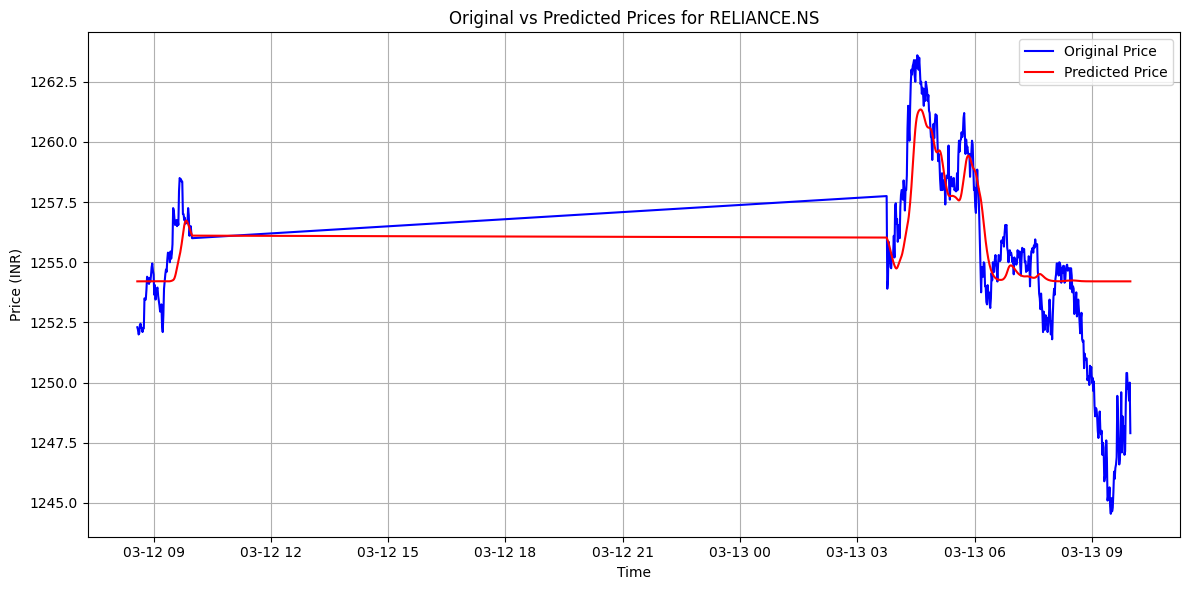

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Datetime'][-len(y_test)+100:], y_test_original[100:], 'b', label='Original Price')
plt.plot(df['Datetime'][-len(y_predicted)+100:],y_predicted_original[100:], 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.title(f'Original vs Predicted Prices for {ticker_symbol}')
plt.grid()
plt.tight_layout()
plt.savefig('LSTM_Reliance_1min.png')
plt.show()


### Residual plot:

This code calculates the residuals (differences between the actual and predicted values) to evaluate the model's performance. A scatter plot is created to visualize the residuals against the predicted values. A horizontal red dashed line at y=0 represents the ideal scenario where residuals are zero (perfect predictions). The plot helps identify patterns or systematic errors in the model's predictions, such as heteroscedasticity (uneven variance) or bias. The visualization is saved as an image file (LSTM_Reliance_1min_residual.png) and displayed for analysis.

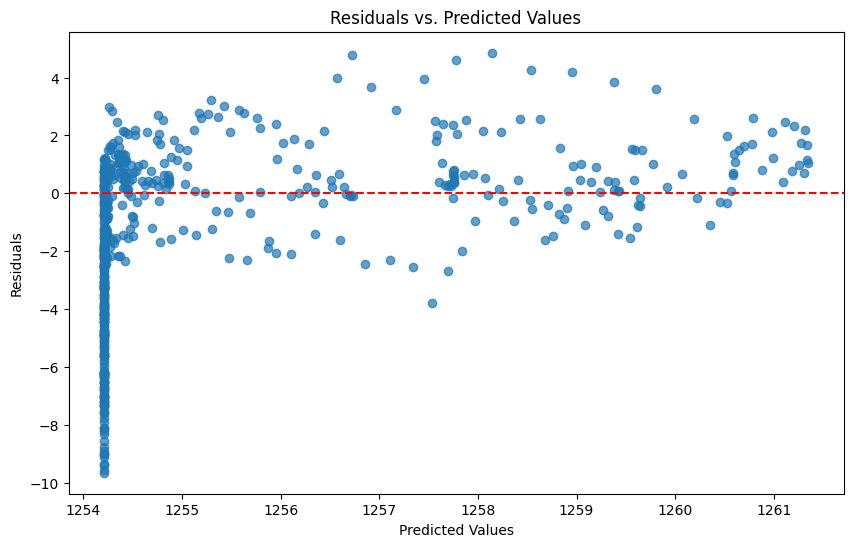

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(10, 6))

# Residuals vs. Predicted Values
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.savefig('LSTM_Reliance_1min_residual.png')
plt.show()

### Residual Histogram

This code creates a histogram to analyze the distribution of residuals (differences between actual and predicted values). The residuals are binned into 20 intervals, with black edges for clarity. The histogram provides insights into the spread and central tendency of the residuals, helping to assess whether they are normally distributed or exhibit skewness/bias. The plot is titled "Residuals Histogram" and includes labeled axes for interpretability. It is saved as an image file (LSTM_Reliance_1min_histogram.png) and displayed for further analysis.

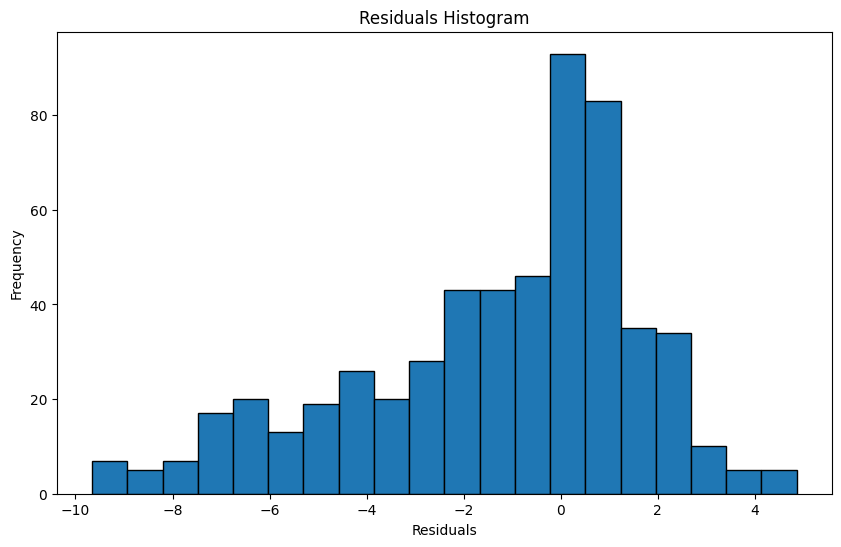

In [ ]:
plt.figure(figsize=(10, 6))

# Residuals Histogram
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.savefig('LSTM_Reliance_1min_histogram.png')
plt.show()

### Errors

The model's performance is evaluated using three metrics:

* MAPE : Mean Absolute Percentage Error, measuring average percentage deviation.
* RMSE : Root Mean Squared Error, emphasizing larger errors.
* MAE : Mean Absolute Error, representing the average absolute deviation.

These metrics are calculated and printed to assess prediction accuracy.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - y_predicted_original) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_predicted_original))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_predicted_original)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.18%
Root Mean Squared Error: 3.189778407528884
Mean Absolute Error: 2.310914396173414


Text(0, 0.5, 'Residuals')

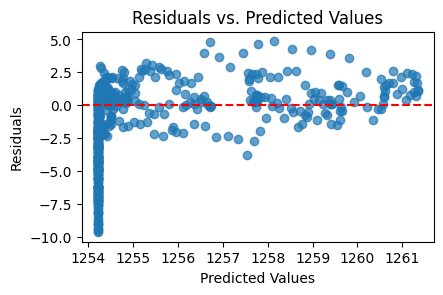

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(10, 6))

# Residuals vs. Predicted Values
plt.subplot(2, 2, 2)
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

## 2 minutes data

**2 minutes for 1 months**

In [ ]:
df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
df = df.reset_index()
df



[*********************100%***********************]  1 of 1 completed


Price,Datetime,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,2025-03-10 03:46:00+00:00,1250.099976,1250.800049,1248.550049,1248.550049,0
1,2025-03-10 03:47:00+00:00,1245.849976,1250.650024,1245.699951,1250.650024,113998
2,2025-03-10 03:48:00+00:00,1246.699951,1247.900024,1245.300049,1245.849976,110138
3,2025-03-10 03:49:00+00:00,1250.500000,1250.500000,1246.199951,1246.250000,91300
4,2025-03-10 03:50:00+00:00,1251.150024,1251.150024,1249.000000,1250.650024,145297
...,...,...,...,...,...,...
1516,2025-03-17 04:08:00+00:00,1248.599976,1249.400024,1248.599976,1248.750000,40355
1517,2025-03-17 04:09:00+00:00,1248.800049,1249.050049,1248.050049,1248.599976,35708
1518,2025-03-17 04:10:00+00:00,1248.050049,1248.849976,1247.550049,1248.750000,37150


### Close value

**Plot Close value for 30 days in 2 minutes time interval**

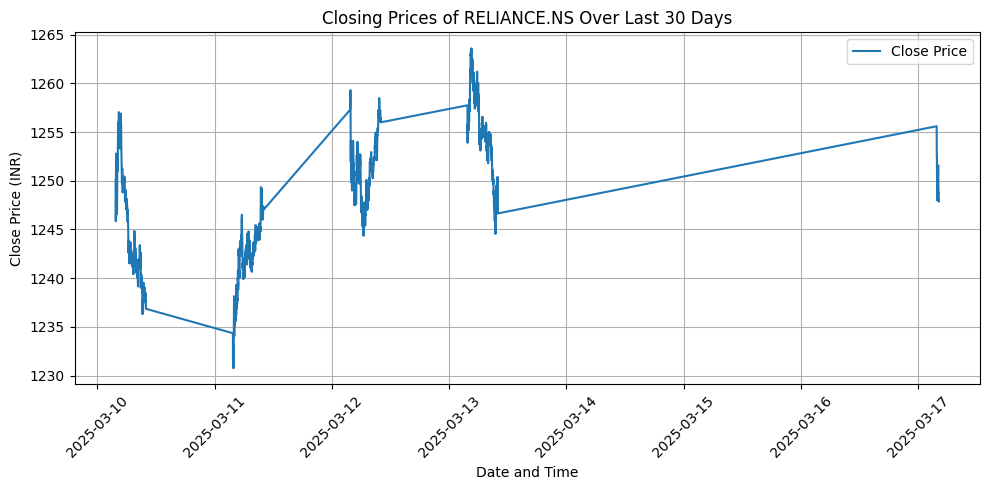

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 30 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

**split the data in train and tast in 70:30**

In [ ]:
# removing Datetime and Adj Close from data
data = df.drop(columns=['Datetime'])

# spliting data into training and testing
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data['Close'][int(len(data)*0.70):int(len(data))])

print(data_testing.shape)
print(data_training.shape)

(457, 1)
(1064, 1)


<ipython-input-33-f324c3630b80>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data = df.drop(columns=['Datetime'])


**Convert the data in  secaler form**

In [ ]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.6777563 ],
       [0.52889491],
       [0.55866634],
       ...,
       [0.8161124 ],
       [0.79509325],
       [0.80735585]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i, 0])

x_train , y_train = np.array(x_train), np.array(y_train)
print(x_train)
print(y_train)

[[[0.6777563 ]
  [0.52889491]
  [0.55866634]
  ...
  [0.67425454]
  [0.67425454]
  [0.68125807]]

 [[0.52889491]
  [0.55866634]
  [0.69176764]
  ...
  [0.67425454]
  [0.68125807]
  [0.69001462]]

 [[0.55866634]
  [0.69176764]
  [0.71453554]
  ...
  [0.68125807]
  [0.69001462]
  [0.67600756]]

 ...

 [[0.61646044]
  [0.64448312]
  [0.65148665]
  ...
  [0.83712727]
  [0.83187248]
  [0.80210106]]

 [[0.64448312]
  [0.65148665]
  [0.66899975]
  ...
  [0.83187248]
  [0.80210106]
  [0.8161124 ]]

 [[0.65148665]
  [0.66899975]
  [0.66725101]
  ...
  [0.80210106]
  [0.8161124 ]
  [0.79509325]]]
[0.69001462 0.67600756 0.68651286 0.6777563  0.66899975 0.68651286
 0.68301109 0.6777563  0.6497379  0.64098135 0.59894733 0.60945691
 0.61471169 0.60070035 0.63572656 0.62871876 0.62871876 0.62171522
 0.62346824 0.63047178 0.63922833 0.64098135 0.61120565 0.58318725
 0.57968548 0.57092893 0.57968548 0.61120565 0.59894733 0.58318725
 0.60070035 0.60420212 0.60420212 0.60070035 0.5919438  0.58318725
 0.5

### Train the model

In [ ]:
model = LSTM_model(x_train)

model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - loss: 0.1433
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 259ms/step - loss: 0.0168
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 292ms/step - loss: 0.0126
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - loss: 0.0124
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 226ms/step - loss: 0.0106
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 294ms/step - loss: 0.0117
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step - loss: 0.0095
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - loss: 0.0120
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - loss: 0.0089
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step - loss: 0.0085
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - loss: 0.0086
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 269ms/step - loss: 0.0093
Epoch 13/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 284ms/step - loss: 0.0087
Epoch 14/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 230ms/step - loss: 0.0089
Epoch 15/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/s

In [ ]:
past_100 = data_training.tail(100)
final_df = pd.concat([past_100, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test)
print(y_test)

[[[0.27821245]
  [0.27559161]
  [0.27296437]
  ...
  [0.49868958]
  [0.46718827]
  [0.48556617]]

 [[0.27559161]
  [0.27296437]
  [0.24934479]
  ...
  [0.46718827]
  [0.48556617]
  [0.49081425]]

 [[0.27296437]
  [0.24934479]
  [0.21784348]
  ...
  [0.48556617]
  [0.49081425]
  [0.49343509]]

 ...

 [[0.43832061]
  [0.38057889]
  [0.3753244 ]
  ...
  [0.22047073]
  [0.2125954 ]
  [0.22309797]]

 [[0.38057889]
  [0.3753244 ]
  [0.37795165]
  ...
  [0.2125954 ]
  [0.22309797]
  [0.18372774]]

 [[0.3753244 ]
  [0.37795165]
  [0.31758268]
  ...
  [0.22309797]
  [0.18372774]
  [0.17322517]]]
[0.49081425 0.49343509 0.4750636  0.46456743 0.45406486 0.44094145
 0.4435687  0.45669211 0.40944655 0.39632314 0.43307253 0.49081425
 0.5065585  0.52230916 0.53280532 0.52755724 0.55380406 0.56955471
 0.56692747 0.55905214 0.54855598 0.57217555 0.5564313  0.56692747
 0.58792621 0.66666667 0.66141858 0.64304709 0.62992368 0.6377926
 0.64041985 0.62729644 0.64041985 0.62992368 0.70340965 0.73228372
 0.72

### Tast Model

In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step


In [ ]:
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_predicted_original = scaler.inverse_transform(y_predicted)

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

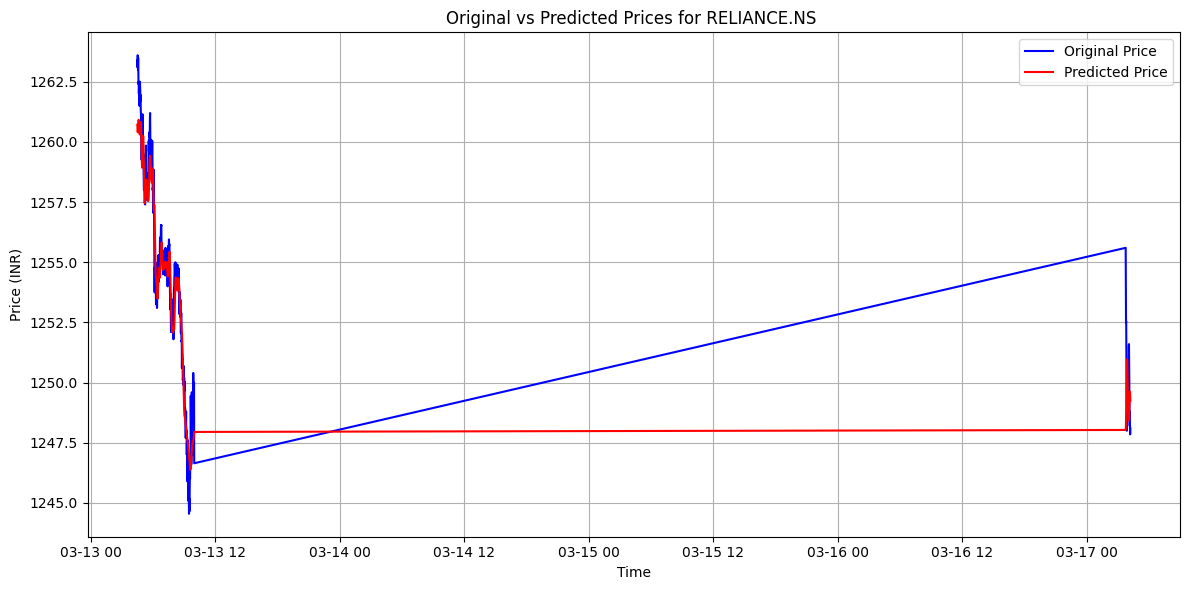

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Datetime'][-len(y_test)+100:], y_test_original[100:], 'b', label='Original Price')
plt.plot(df['Datetime'][-len(y_predicted)+100:],y_predicted_original[100:], 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.title(f'Original vs Predicted Prices for {ticker_symbol} ')
plt.grid()
plt.tight_layout()
plt.savefig('LSTM_Reliance_2min.png')
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

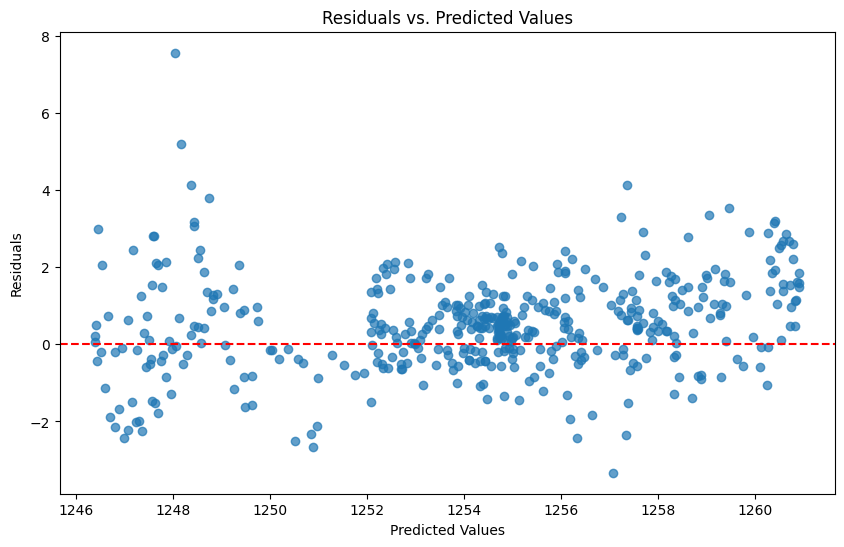

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(10, 6))

# Residuals vs. Predicted Values
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.savefig('LSTM_Reliance_2min_residual.png')

### Residual Histogram

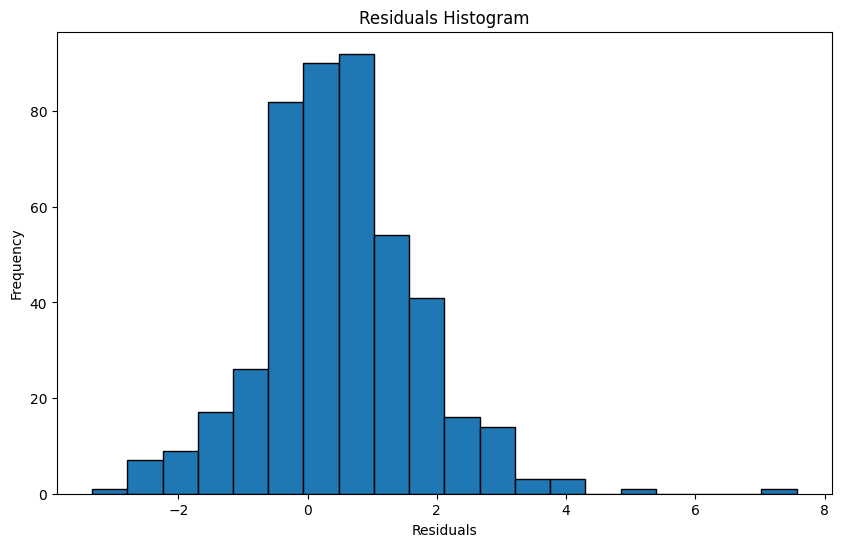

In [ ]:
plt.figure(figsize=(10, 6))

# Residuals Histogram
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.savefig('LSTM_Reliance_2min_histogram.png')
plt.show()

### Errors

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - y_predicted_original) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_predicted_original))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_predicted_original)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.08%
Root Mean Squared Error: 1.3381338349228267
Mean Absolute Error: 1.0065629487486274


## 1 day data

1 day data form begining

In [ ]:
df = yf.download(tickers=ticker_symbol)
df = df.reset_index()
df

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
0,1996-01-01,3.559201,3.565256,3.522874,3.546227,104121369
1,1996-01-02,3.531525,3.567852,3.505577,3.550554,168743308
2,1996-01-03,3.558337,3.752947,3.550553,3.589474,209323879
3,1996-01-04,3.525469,3.535848,3.477898,3.524604,216900264
4,1996-01-05,3.501252,3.511631,3.470979,3.511631,166708467
...,...,...,...,...,...,...
7329,2025-03-10,1238.400024,1258.000000,1235.400024,1245.000000,11931051
7330,2025-03-11,1247.300049,1249.500000,1229.750000,1240.000000,10089838
7331,2025-03-12,1257.050049,1263.000000,1244.000000,1258.000000,11977555


### Close value


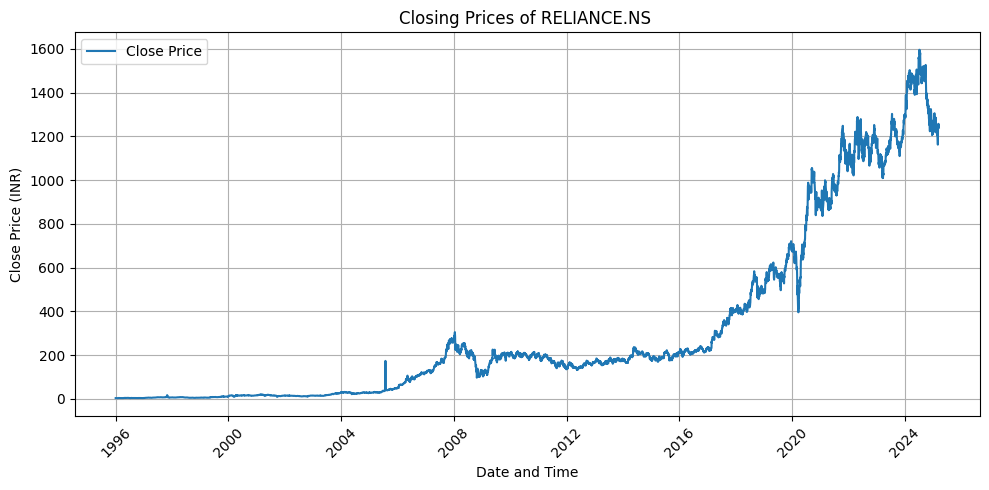

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} ')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

**split the data in train and tast in 70:30**

In [ ]:
# removing Date and Adj Close from data
data = df.drop(columns=['Date'])

# spliting data into training and testing
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data['Close'][int(len(data)*0.70):int(len(data))])

print(data_testing.shape)
print(data_training.shape)

(2201, 1)
(5133, 1)


<ipython-input-61-76897e4c1869>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data = df.drop(columns=['Date'])


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[-1.0606789 ],
       [-1.06100315],
       [-1.06068903],
       ...,
       [ 1.5977266 ],
       [ 1.52811589],
       [ 1.53787937]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i, 0])

x_train , y_train = np.array(x_train), np.array(y_train)
print(x_train.shape)
print(y_train.shape)

(5033, 100, 1)
(5033,)


### Train the model

In [ ]:
model = LSTM_model(x_train)

model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 53s 262ms/step - loss: 0.6237
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - loss: 0.0509
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - loss: 0.0394
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 265ms/step - loss: 0.0402
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - loss: 0.0355
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 263ms/step - loss: 0.0328
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 264ms/step - loss: 0.0296
Epoch 8/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 42s 264ms/step - loss: 0.0315
Epoch 9/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 81s 258ms/step - loss: 0.0291
Epoch 10/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - loss: 0.0305
Epoch 11/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 260ms/step - loss: 0.0254
Epoch 12/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 261ms/step - loss: 0.0286
Epoch 13/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 262ms/step - loss: 0.0278
Epoch 14/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 82s 260ms/step - loss: 0.0281
Epoch 15/50
158

In [ ]:
past_100 = data_training.tail(100)
final_df = pd.concat([past_100, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test)
print(y_test)

[[[-1.45027015]
  [-1.4430372 ]
  [-1.43217489]
  ...
  [-1.38014472]
  [-1.39470143]
  [-1.39265973]]

 [[-1.4430372 ]
  [-1.43217489]
  [-1.43715239]
  ...
  [-1.39470143]
  [-1.39265973]
  [-1.39382643]]

 [[-1.43217489]
  [-1.43715239]
  [-1.44334833]
  ...
  [-1.39265973]
  [-1.39382643]
  [-1.40551948]]

 ...

 [[ 1.38533627]
  [ 1.4095898 ]
  [ 1.34626058]
  ...
  [ 1.11707492]
  [ 1.08914628]
  [ 1.11095023]]

 [[ 1.4095898 ]
  [ 1.34626058]
  [ 1.33444005]
  ...
  [ 1.08914628]
  [ 1.11095023]
  [ 1.13483652]]

 [[ 1.34626058]
  [ 1.33444005]
  [ 1.3375637 ]
  ...
  [ 1.11095023]
  [ 1.13483652]
  [ 1.1124201 ]]]
[-1.39382643 -1.40551948 -1.40549302 ...  1.13483652  1.1124201
  1.09306602]


### Tast Model

In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step


In [ ]:
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_predicted_original = scaler.inverse_transform(y_predicted)

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

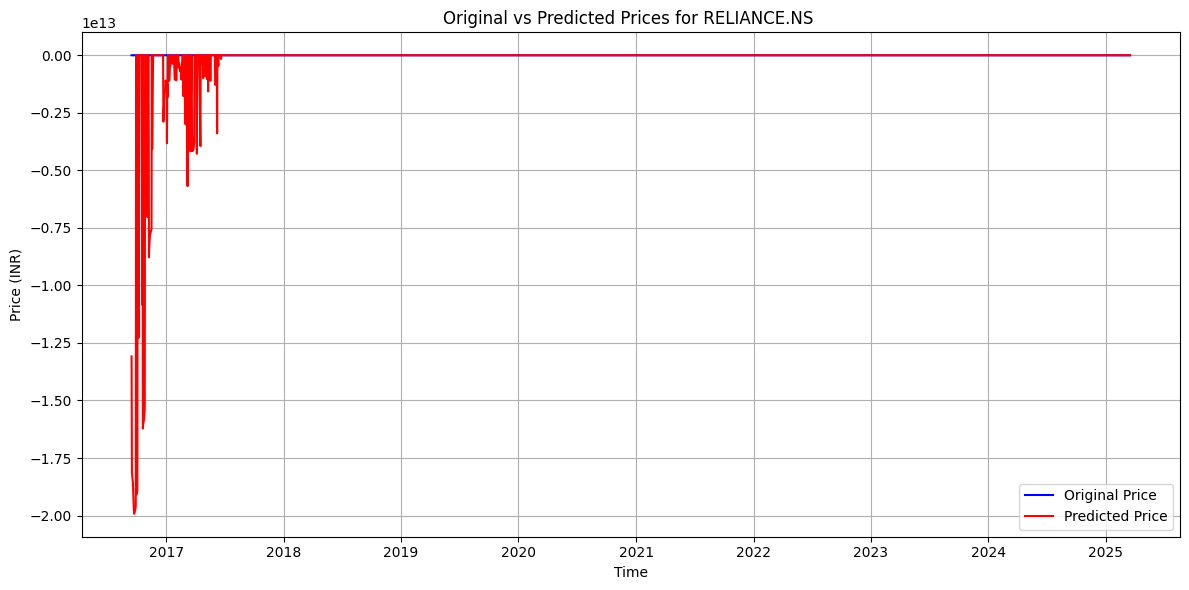

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'][-len(y_test)+100:], y_test_original[100:], 'b', label='Original Price')
plt.plot(df['Date'][-len(y_predicted)+100:],y_predicted_original[100:], 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.title(f'Original vs Predicted Prices for {ticker_symbol} ')
plt.grid()
plt.tight_layout()
plt.savefig('LSTM_Reliance_1day.png')
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

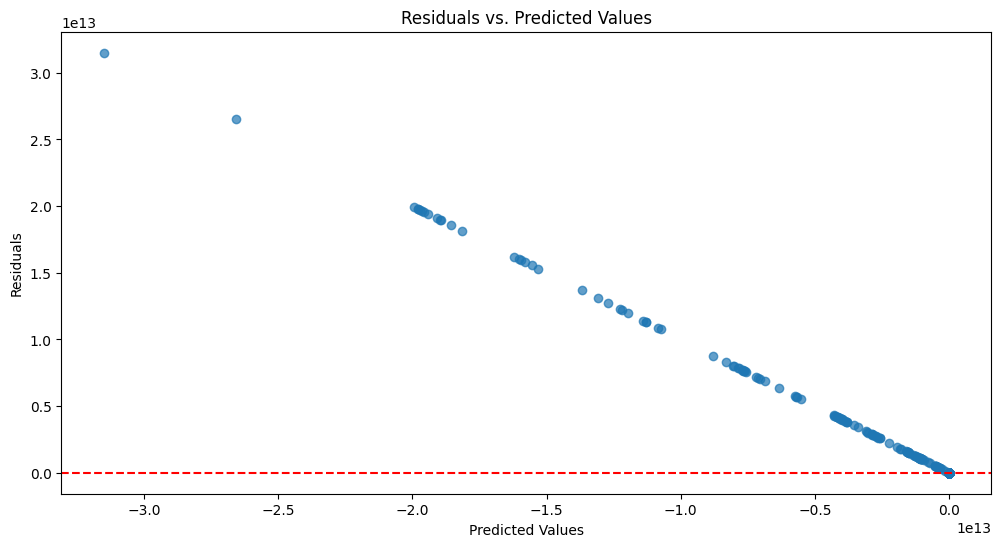

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(12, 6))

# Residuals vs. Predicted Values
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.savefig('LSTM_Reliance_1day_residual.png')

### Residual Histogram

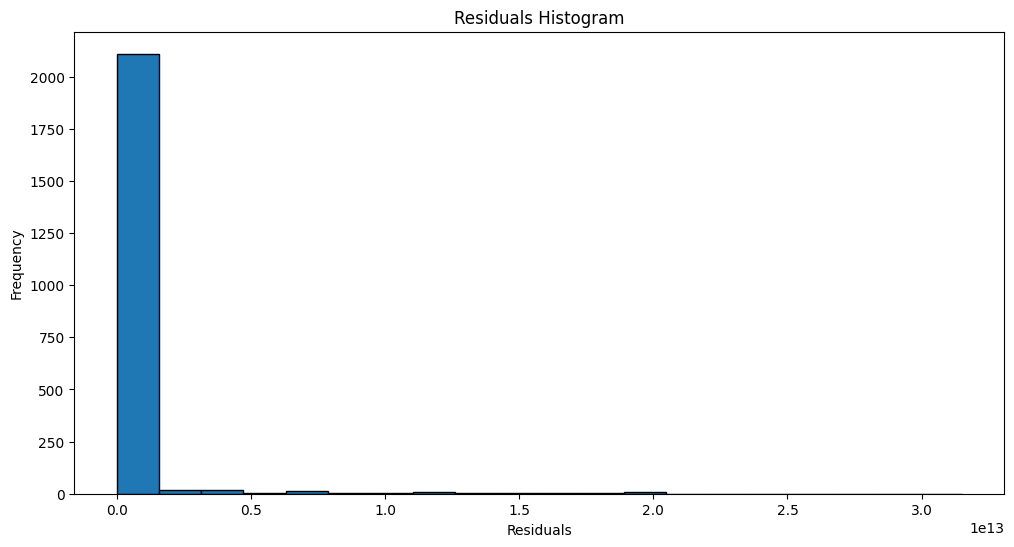

In [ ]:
plt.figure(figsize=(12, 6))

# Residuals Histogram
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.savefig('LSTM_Reliance_1day_histogram.png')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - y_predicted_original) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_predicted_original))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_predicted_original)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 167192210754.36%
Root Mean Squared Error: 2220546829234.152
Mean Absolute Error: 379191786652.6235


# TCS

In [ ]:
ticker_symbol = "TCS.NS"

## 1 minute data

In [ ]:
df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
df = df.reset_index()
df



[*********************100%***********************]  1 of 1 completed


Price,Datetime,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2025-01-28 03:45:00+00:00,4089.800049,4091.600098,4066.199951,4077.199951,0
1,2025-01-28 03:46:00+00:00,4082.850098,4093.699951,4080.000000,4090.000000,19059
2,2025-01-28 03:47:00+00:00,4077.149902,4085.649902,4074.399902,4082.699951,15408
3,2025-01-28 03:48:00+00:00,4078.149902,4080.850098,4076.100098,4076.899902,11932
4,2025-01-28 03:49:00+00:00,4079.149902,4084.250000,4078.149902,4078.149902,11070
...,...,...,...,...,...,...
1495,2025-01-31 09:55:00+00:00,4110.250000,4112.799805,4109.649902,4112.549805,19491
1496,2025-01-31 09:56:00+00:00,4111.899902,4113.600098,4110.250000,4110.350098,12596
1497,2025-01-31 09:57:00+00:00,4112.049805,4113.450195,4107.000000,4113.450195,17900


### Close Value

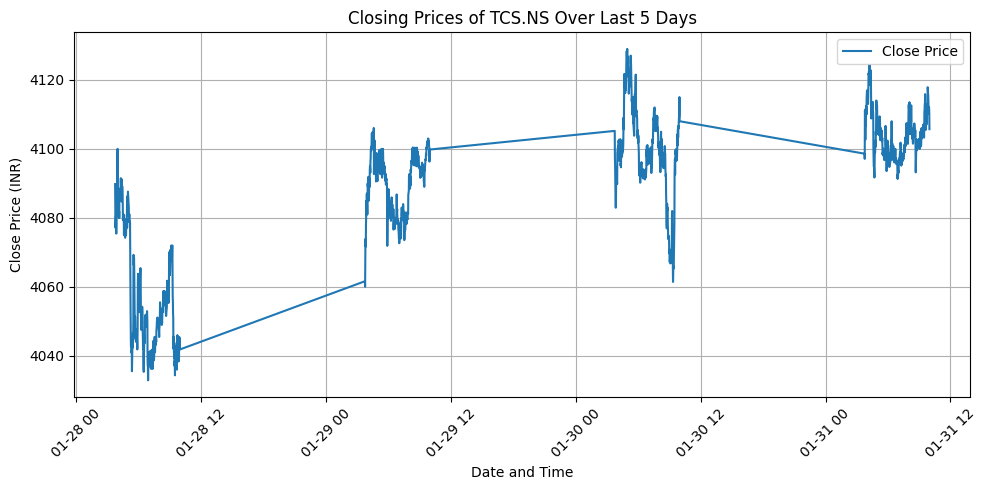

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

**split the data in train and tast in 70:30**

In [ ]:
# removing Datetime and Adj Close from data
data = df.drop(columns=['Datetime'])

# spliting data into training and testing
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data['Close'][int(len(data)*0.70):int(len(data))])

print(data_testing.shape)
print(data_training.shape)

(450, 1)
(1050, 1)


<ipython-input-21-f324c3630b80>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data = df.drop(columns=['Datetime'])


**Convert the data in  secaler form**

In [ ]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[ 0.34218719],
       [ 0.03904831],
       [-0.20957945],
       ...,
       [ 0.13282149],
       [ 0.01723961],
       [-0.17250039]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i, 0])

x_train , y_train = np.array(x_train), np.array(y_train)
print(x_train)
print(y_train)

[[[ 0.34218719]
  [ 0.03904831]
  [-0.20957945]
  ...
  [-2.02187438]
  [-1.9106585 ]
  [-1.71438015]]

 [[ 0.03904831]
  [-0.20957945]
  [-0.16596204]
  ...
  [-1.9106585 ]
  [-1.71438015]
  [-1.64240503]]

 [[-0.20957945]
  [-0.16596204]
  [-0.12234463]
  ...
  [-1.71438015]
  [-1.64240503]
  [-1.7252845 ]]

 ...

 [[ 0.63659407]
  [ 0.64315372]
  [ 0.61915137]
  ...
  [ 0.43814337]
  [ 0.46213507]
  [ 0.21351796]]

 [[ 0.64315372]
  [ 0.61915137]
  [ 0.66713478]
  ...
  [ 0.46213507]
  [ 0.21351796]
  [ 0.13282149]]

 [[ 0.61915137]
  [ 0.66713478]
  [ 0.77181231]
  ...
  [ 0.21351796]
  [ 0.13282149]
  [ 0.01723961]]]
[-1.64240503e+00 -1.72528450e+00 -1.59006626e+00 -1.53772750e+00
 -1.62714532e+00 -1.38942191e+00 -5.51969741e-01 -5.65057095e-01
 -6.82821976e-01 -5.89048801e-01 -7.11179682e-01 -9.37988092e-01
 -1.08192768e+00 -1.36107485e+00 -1.58352791e+00 -1.32836179e+00
 -1.41777962e+00 -1.60097062e+00 -1.49192709e+00 -1.50936979e+00
 -1.65112638e+00 -1.50283144e+00 -1.56825756e

### Train the model

In [ ]:
model = LSTM_model(x_train)

model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 352ms/step - loss: 3504085.7500
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - loss: 0.6161
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step - loss: 0.6734
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 265ms/step - loss: 0.6301
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 355ms/step - loss: 0.4048
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 332ms/step - loss: 0.6648
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - loss: 0.4805
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 349ms/step - loss: 0.5043
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 272ms/step - loss: 0.5079
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - loss: 0.4687
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 358ms/step - loss: 212399.3750
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 265ms/step - loss: 0.7240
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 312ms/step - loss: 0.7843
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 359ms/step - loss: 0.5399
Epoch 15/50
30/30 ━━━━━━━━━━━━━━━

In [ ]:
past_100 = data_training.tail(100)
final_df = pd.concat([past_100, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

### Tast Model

In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step


In [ ]:
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_predicted_original = scaler.inverse_transform(y_predicted)

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

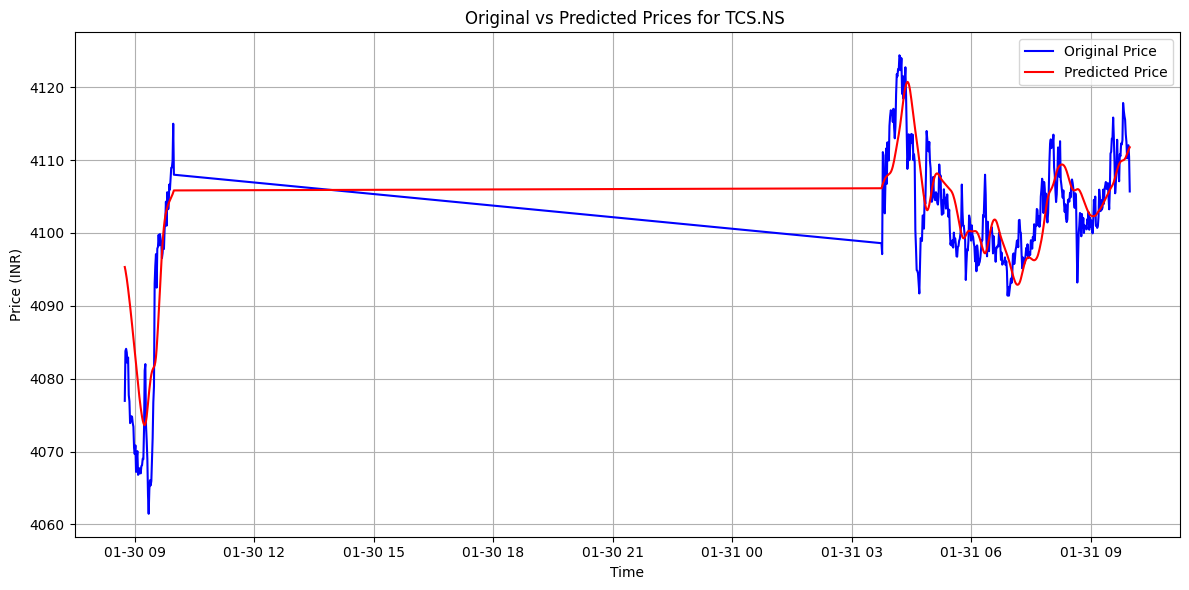

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Datetime'][-len(y_test):], y_test_original, 'b', label='Original Price')
plt.plot(df['Datetime'][-len(y_predicted):],y_predicted_original, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.title(f'Original vs Predicted Prices for {ticker_symbol} ')
plt.grid()
plt.tight_layout()
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

Text(0, 0.5, 'Residuals')

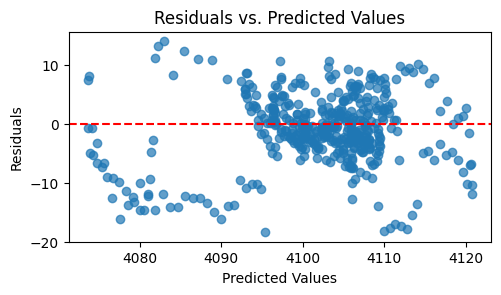

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(12, 6))

# Residuals vs. Predicted Values
plt.subplot(2, 2, 2)
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

### Residual Histogram

Text(0, 0.5, 'Frequency')

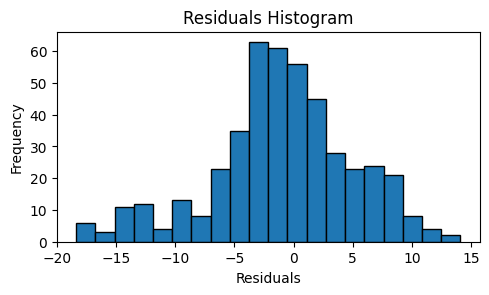

In [ ]:
plt.figure(figsize=(12, 6))

# Residuals Histogram
plt.subplot(2, 2, 3)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

### Errors

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - y_predicted_original) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_predicted_original))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_predicted_original)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.11%
Root Mean Squared Error: 6.035970727856118
Mean Absolute Error: 4.567511935763889


## 2 minutes data

In [ ]:
df = yf.download(tickers=ticker_symbol, period="5d", interval="1m")
df = df.reset_index()
df


[*********************100%***********************]  1 of 1 completed


Price,Datetime,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2025-01-28 03:45:00+00:00,4089.800049,4091.600098,4066.199951,4077.199951,0
1,2025-01-28 03:46:00+00:00,4082.850098,4093.699951,4080.000000,4090.000000,19059
2,2025-01-28 03:47:00+00:00,4077.149902,4085.649902,4074.399902,4082.699951,15408
3,2025-01-28 03:48:00+00:00,4078.149902,4080.850098,4076.100098,4076.899902,11932
4,2025-01-28 03:49:00+00:00,4079.149902,4084.250000,4078.149902,4078.149902,11070
...,...,...,...,...,...,...
1495,2025-01-31 09:55:00+00:00,4110.250000,4112.799805,4109.649902,4112.549805,19491
1496,2025-01-31 09:56:00+00:00,4111.899902,4113.600098,4110.250000,4110.350098,12596
1497,2025-01-31 09:57:00+00:00,4112.049805,4113.450195,4107.000000,4113.450195,17900


### Close Value

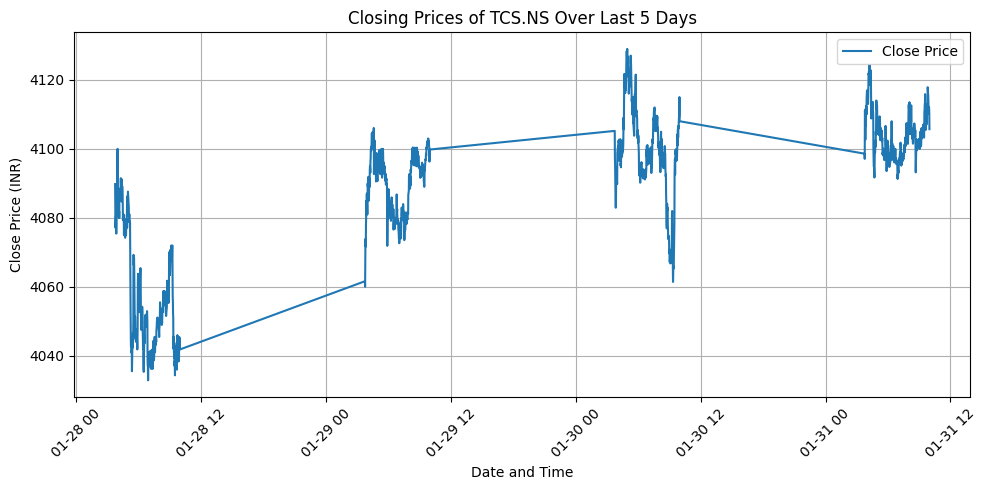

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Datetime'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} Over Last 5 Days')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

**split the data in train and tast in 70:30**

In [ ]:
# removing Datetime and Adj Close from data
data = df.drop(columns=['Datetime'])

# spliting data into training and testing
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data['Close'][int(len(data)*0.70):int(len(data))])

print(data_testing.shape)
print(data_training.shape)

(450, 1)
(1050, 1)


<ipython-input-42-f324c3630b80>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data = df.drop(columns=['Datetime'])


**Convert the data in  secaler form**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.59218701],
       [0.51979187],
       [0.46041499],
       ...,
       [0.54218663],
       [0.51458355],
       [0.46927015]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i, 0])

x_train , y_train = np.array(x_train), np.array(y_train)
print(x_train)
print(y_train)

[[[0.59218701]
  [0.51979187]
  [0.46041499]
  ...
  [0.02760562]
  [0.05416602]
  [0.1010409 ]]

 [[0.51979187]
  [0.46041499]
  [0.47083163]
  ...
  [0.05416602]
  [0.1010409 ]
  [0.11822988]]

 [[0.46041499]
  [0.47083163]
  [0.48124827]
  ...
  [0.1010409 ]
  [0.11822988]
  [0.09843674]]

 ...

 [[0.66249679]
  [0.66406335]
  [0.65833115]
  ...
  [0.61510311]
  [0.62083277]
  [0.56145843]]

 [[0.66406335]
  [0.65833115]
  [0.66979047]
  ...
  [0.62083277]
  [0.56145843]
  [0.54218663]]

 [[0.65833115]
  [0.66979047]
  [0.69478939]
  ...
  [0.56145843]
  [0.54218663]
  [0.51458355]]]
[0.11822988 0.09843674 0.13072934 0.1432288  0.12187418 0.1786469
 0.37864589 0.37552039 0.34739597 0.36979073 0.34062363 0.2864576
 0.25208218 0.1854167  0.13229082 0.19322918 0.17187456 0.12812518
 0.15416678 0.15000114 0.11614706 0.15156262 0.13593766 0.136459
 0.15208396 0.13749914 0.13072934 0.11145754 0.09322842 0.1135429
 0.17447872 0.29166592 0.32135437 0.2734368  0.26406285 0.23958272
 0.271353

### Train the model

In [ ]:
model = LSTM_model(x_train)

model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 16s 266ms/step - loss: 0.1702
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 325ms/step - loss: 0.0247
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 355ms/step - loss: 0.0189
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 339ms/step - loss: 0.0150
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 271ms/step - loss: 0.0145
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step - loss: 0.0136
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 355ms/step - loss: 0.0122
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 335ms/step - loss: 0.0137
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - loss: 0.0134
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 357ms/step - loss: 0.0144
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - loss: 0.0116
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 318ms/step - loss: 0.0101
Epoch 13/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - loss: 0.0100
Epoch 14/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 316ms/step - loss: 0.0097
Epoch 15/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 3

In [ ]:
past_100 = data_training.tail(100)
final_df = pd.concat([past_100, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

### Tast Model

In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step


In [ ]:
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_predicted_original = scaler.inverse_transform(y_predicted)

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

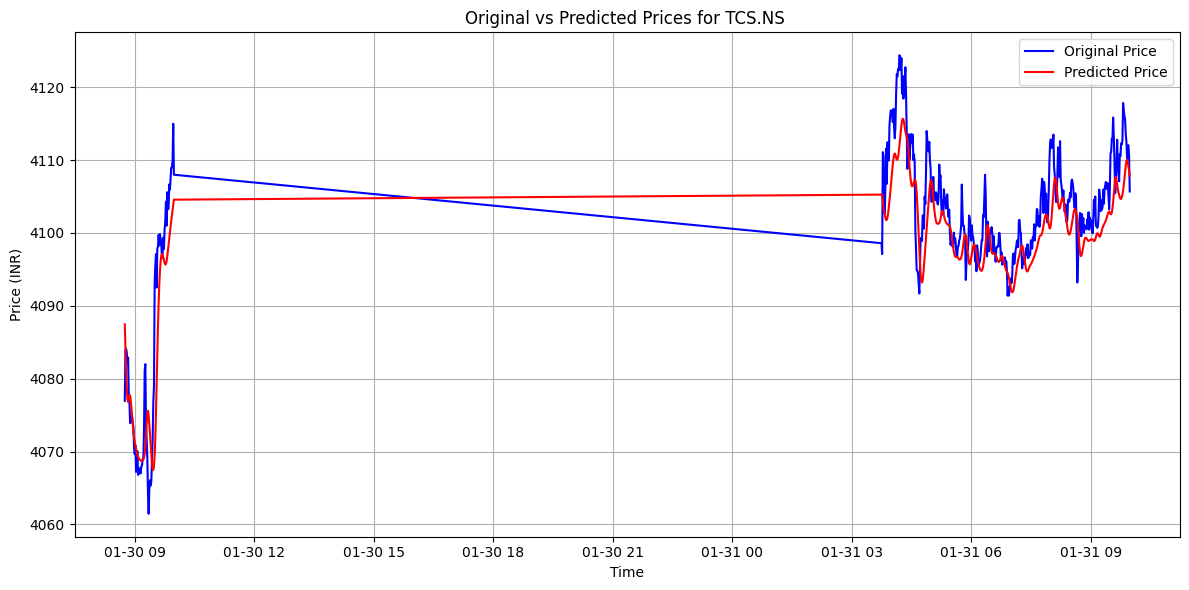

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Datetime'][-len(y_test):], y_test_original, 'b', label='Original Price')
plt.plot(df['Datetime'][-len(y_predicted):],y_predicted_original, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.title(f'Original vs Predicted Prices for {ticker_symbol} ')
plt.grid()
plt.tight_layout()
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

Text(0, 0.5, 'Residuals')

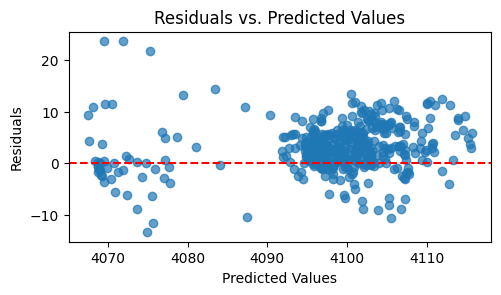

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(12, 6))

# Residuals vs. Predicted Values
plt.subplot(2, 2, 2)
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

### Residual Histogram

Text(0, 0.5, 'Frequency')

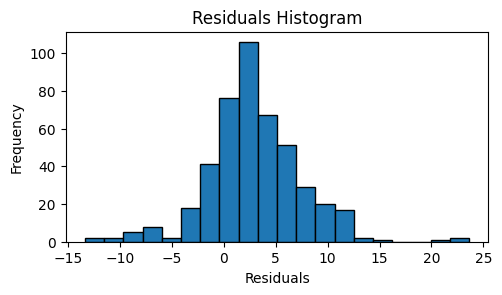

In [ ]:
plt.figure(figsize=(12, 6))

# Residuals Histogram
plt.subplot(2, 2, 3)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

### Errors

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - y_predicted_original) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_predicted_original))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_predicted_original)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 0.10%
Root Mean Squared Error: 5.4390262547758885
Mean Absolute Error: 4.134477539062489


## 1 day data

In [ ]:
df = yf.download(tickers=ticker_symbol)
df = df.reset_index()
df

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
0,2002-08-12,28.609932,28.826127,27.907293,27.907293,212976
1,2002-08-13,28.222574,29.105376,28.015388,28.645959,153576
2,2002-08-14,26.276808,28.285627,25.745324,28.285627,822776
3,2002-08-15,26.276808,26.276808,26.276808,26.276808,0
4,2002-08-16,26.213749,27.384810,25.763341,26.141685,811856
...,...,...,...,...,...,...
5576,2025-01-28,4040.300049,4102.000000,4028.300049,4070.800049,2468272
5577,2025-01-29,4099.799805,4107.850098,4054.000000,4054.000000,1217089
5578,2025-01-30,4100.049805,4129.899902,4058.500000,4099.899902,1531251


### Close value


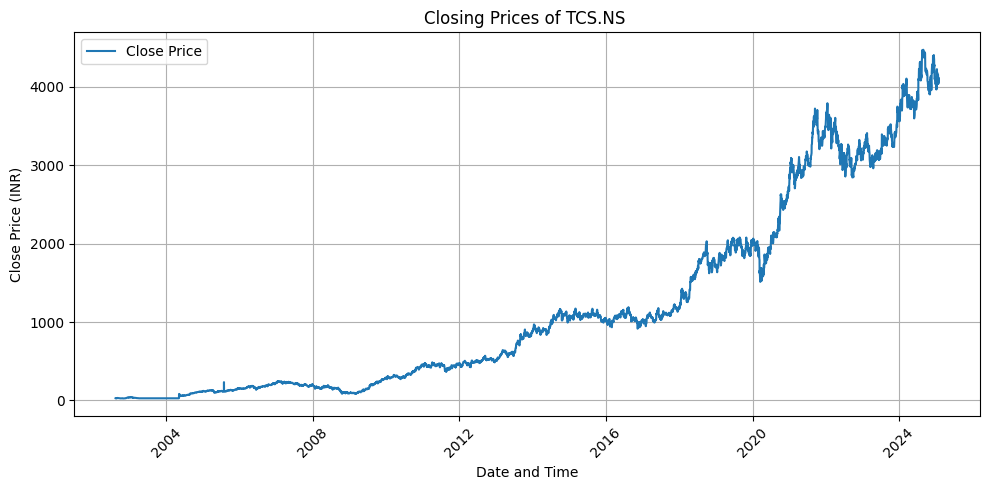

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.title(f'Closing Prices of {ticker_symbol} ')
plt.xlabel('Date and Time')
plt.ylabel('Close Price (INR)')
plt.xticks(rotation=45)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Data Split

**split the data in train and tast in 70:30**

In [ ]:
# removing Date and Adj Close from data
data = df.drop(columns=['Date'])

# spliting data into training and testing
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_testing = pd.DataFrame(data['Close'][int(len(data)*0.70):int(len(data))])

print(data_testing.shape)
print(data_training.shape)

(1675, 1)
(3906, 1)


<ipython-input-55-76897e4c1869>:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  data = df.drop(columns=['Date'])


In [ ]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[2.04063001e-03],
       [1.78101880e-03],
       [4.76945658e-04],
       ...,
       [9.35098636e-01],
       [9.98149722e-01],
       [1.00000000e+00]])

In [ ]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i, 0])

x_train , y_train = np.array(x_train), np.array(y_train)
print(x_train)
print(y_train)

[[[2.04063001e-03]
  [1.78101880e-03]
  [4.76945658e-04]
  ...
  [8.82058009e-03]
  [9.55713312e-03]
  [8.95341341e-03]]

 [[1.78101880e-03]
  [4.76945658e-04]
  [4.76945658e-04]
  ...
  [9.55713312e-03]
  [8.95341341e-03]
  [1.04687988e-02]]

 [[4.76945658e-04]
  [4.76945658e-04]
  [4.34682951e-04]
  ...
  [8.95341341e-03]
  [1.04687988e-02]
  [1.18996409e-02]]

 ...

 [[7.80874049e-01]
  [7.81052892e-01]
  [7.83077104e-01]
  ...
  [9.34053805e-01]
  [9.27772954e-01]
  [9.25534801e-01]]

 [[7.81052892e-01]
  [7.83077104e-01]
  [7.82422275e-01]
  ...
  [9.27772954e-01]
  [9.25534801e-01]
  [9.35098636e-01]]

 [[7.83077104e-01]
  [7.82422275e-01]
  [7.82258567e-01]
  ...
  [9.25534801e-01]
  [9.35098636e-01]
  [9.98149722e-01]]]
[0.0104688  0.01189964 0.01237056 ... 0.93509864 0.99814972 1.        ]


### Train the model

In [ ]:
model = LSTM_model(x_train)

model.compile(optimizer='adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs=50)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 45s 309ms/step - loss: 0.0430
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 324ms/step - loss: 0.0055
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 37s 310ms/step - loss: 0.0049
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 310ms/step - loss: 0.0044
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 38s 320ms/step - loss: 0.0043
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 40s 312ms/step - loss: 0.0031
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 327ms/step - loss: 0.0032
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 310ms/step - loss: 0.0032
Epoch 9/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 329ms/step - loss: 0.0030
Epoch 10/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 39s 311ms/step - loss: 0.0027
Epoch 11/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 310ms/step - loss: 0.0025
Epoch 12/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 43s 328ms/step - loss: 0.0030
Epoch 13/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 37s 310ms/step - loss: 0.0028
Epoch 14/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 41s 309ms/step - loss: 0.0024
Epoch 15/50
119

In [ ]:
past_100 = data_training.tail(100)
final_df = pd.concat([past_100, data_testing], ignore_index=True)
input_data = scaler.fit_transform(final_df)

x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test)
print(y_test)

[[[0.01864756]
  [0.01857444]
  [0.01496454]
  ...
  [0.08683808]
  [0.11499886]
  [0.11582526]]

 [[0.01857444]
  [0.01496454]
  [0.0121525 ]
  ...
  [0.11499886]
  [0.11582526]
  [0.11275988]]

 [[0.01496454]
  [0.0121525 ]
  [0.01121506]
  ...
  [0.11582526]
  [0.11275988]
  [0.12403505]]

 ...

 [[0.97148912]
  [0.96937285]
  [0.98650869]
  ...
  [0.87839642]
  [0.87095789]
  [0.88876849]]

 [[0.96937285]
  [0.98650869]
  [0.97813188]
  ...
  [0.87095789]
  [0.88876849]
  [0.88884333]]

 [[0.98650869]
  [0.97813188]
  [0.98940401]
  ...
  [0.88876849]
  [0.88884333]
  [0.89254019]]]
[0.11275988 0.12403505 0.13323092 ... 0.88884333 0.89254019 0.88079114]


### Tast Model

In [ ]:
# Making Predictions

y_predicted = model.predict(x_test)

53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step


In [ ]:
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))
y_predicted_original = scaler.inverse_transform(y_predicted)

### Predicted vs Actual:

This plot shows how well a regression model performs. If the predictions perfectly match the actual values, the points should align along a straight line with a slope of one. The closer the points cluster around this line, the more accurate the model's predictions are.

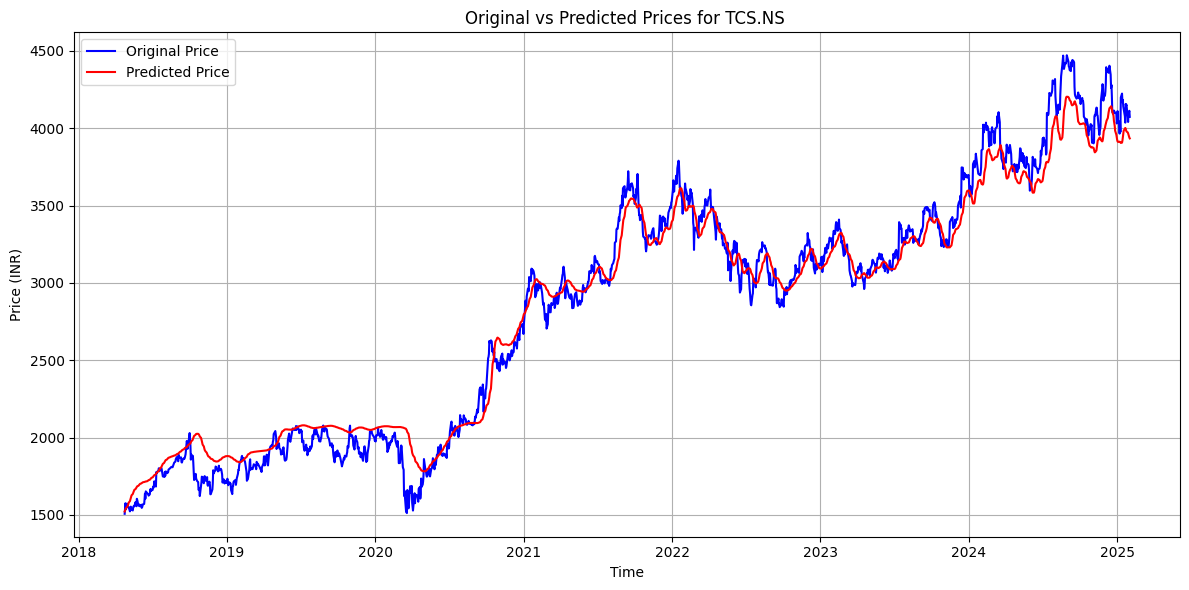

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'][-len(y_test):], y_test_original, 'b', label='Original Price')
plt.plot(df['Date'][-len(y_predicted):],y_predicted_original, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (INR)')
plt.legend()
plt.title(f'Original vs Predicted Prices for {ticker_symbol} ')
plt.grid()
plt.tight_layout()
plt.show()

### Residual plot:

This plot offering insight into the relationship between observed and predicted values. Residuals distributed randomly around y = 0 indicate a well-captured data structure, whereas patterns or trends indicate model inadequacy. A good model will have residuals dispersed around zero, shown by a red dashed line. This plot is crucial tool in regression analysis.

Text(0, 0.5, 'Residuals')

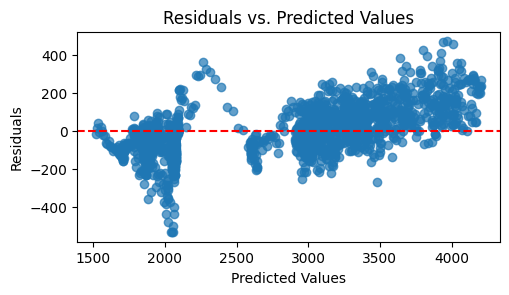

In [ ]:
# Calculate residuals
residuals = y_test_original - y_predicted_original
plt.figure(figsize=(12, 6))

# Residuals vs. Predicted Values
plt.subplot(2, 2, 2)
plt.scatter(y_predicted_original, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

### Residual Histogram

Text(0, 0.5, 'Frequency')

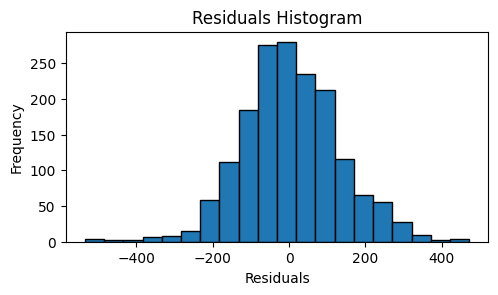

In [ ]:
plt.figure(figsize=(12, 6))

# Residuals Histogram
plt.subplot(2, 2, 3)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Residuals Histogram')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

### Errors

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate MAPE
mape = np.mean(np.abs((y_test_original - y_predicted_original) / y_test_original)) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_original, y_predicted_original))
print(f"Root Mean Squared Error: {rmse}")

# Calculate MAE
mae = mean_absolute_error(y_test_original, y_predicted_original)
print(f"Mean Absolute Error: {mae}")

Mean Absolute Percentage Error: 3.84%
Root Mean Squared Error: 129.39827698478132
Mean Absolute Error: 99.63020668143656
